In [1]:
import numpy as np

from wrapastac import Sentinel2
from wrapastac.geometry import point_to_bbox

geom = point_to_bbox(lat=25.22698556685387, lon=55.164956245291705, buffer_m=5120)


s2 = Sentinel2(provider="planetary_computer")
items = s2.search(geometry=geom, start="2025-01-12", end="2025-12-30", cloud_cover=10)
print(items)

ds = s2.load(
    items, geometry=geom, bands=["red", "green", "blue", "scl"], nodata=np.nan, dtype=np.float32
)

ItemCollection(112 items)


In [2]:
# Expand item collection filter handling any property or metadata in the item
# Add a filter to xarray dataset to filter by cloud using the SCL and nan values
# Add option to clip based on geometry, or window of specific pixel size
# Run the typecheck and fix

# Add normalisation functions?

In [3]:
import xarray as xr


def filter_cloud(data: xr.Dataset, cloudy_values: list[int] = [8, 9, 10, 11]) -> xr.Dataset:
    """Removes any images from the xarray data object where there are any cloudy classifications in
    the Scene Classification Layer.

    SCL Pixel Values
    ----------------
    0 - No Data (Missing data)
    1 - Saturated or defective pixel
    2 - Topographic casted shadows (called "Dark features/Shadows" for data before 2022-01-25)
    3 - Cloud shadows
    4 - Vegetation
    5 - Not-vegetated
    6 - Water
    7 - Unclassified
    8 - Cloud medium probability
    9 - Cloud high probability
    10 - Thin cirrus
    11 - Snow or ice
    """
    if "scl" not in data:
        raise ValueError("xarray data object does not contain the SCL layer as a band!")

    cloud_mask = data["scl"].isin(cloudy_values).any(dim=("x", "y"))

    original_length = len(data.time)
    data = data.sel(time=~cloud_mask)
    new_length = len(data.time)

    print(
        f"Pre cloud filtering length: {original_length}. After cloud filtering length: {new_length}"
    )

    return data

/var/folders/0_/sjm47g6x0pz0y7jqjsmwrx8c0000gn/T/ipykernel_44881/3189388157.py:11: RuntimeWarning: invalid value encountered in cast
  image = (image * 255).astype(np.uint8)


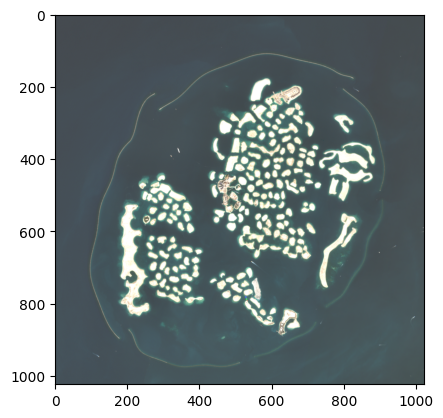

In [4]:
import matplotlib.pyplot as plt


def normalise_tc(da: xr.DataArray, sf: float = 2.5) -> xr.DataArray:
    return (sf * (da / 1e4)).clip(0, 1)


image = ds[["red", "green", "blue"]].isel(time=5).to_array().values
# image = (image - np.nanmin(image)) / (np.nanmax(image) - np.nanmin(image))
image = normalise_tc(image)
image = (image * 255).astype(np.uint8)
image = np.moveaxis(image, 0, -1)

plt.imshow(image)